# Programming Evaluation — Memory vs. No Memory

Plots for a coding-agent evaluation over **20 programming assignments × 2
conditions** (with memory / without memory). Assignments are labelled by
term — `ST` = summer term, `WT` = winter term — with two tasks per term
(`ST21-01` … `WT2526-02`). For each (assignment, condition)
pair there is a score trajectory: iteration 0 (one-shot) through iteration N
(N varies).

Three chart families, one claim each:

| # | Question | Chart | Output name |
|---|---|---|---|
| 1 | Did the feedback loop improve the score? | One-shot / final / delta heatmaps | `score_heatmaps` |
| 2 | Did memory reduce correction cycles? | Grouped bars of loop counts | `loop_counts` |
| 3 | How did scores evolve per assignment? | Small-multiples trajectories | `score_trajectories` |

Each plot is saved twice, matching `plots.ipynb`:

- **PDF** → `output/figures/` (for quick viewing)
- **TikZ / PGFPlots `.tex`** → `output/tikz/` (for `\input{}` into the thesis)

**Data source:** `data/programming_scores.csv` (long format:
`assignment`, `condition`, `iteration`, `score`).

Run all cells top to bottom (`Run All`) to (re-)generate every figure.

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tikzplotlib
from matplotlib.colors import Normalize
from pathlib import Path

%matplotlib inline

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "results" / "programming"
FIGURES_DIR = PROJECT_ROOT / "output" / "figures"
TIKZ_DIR = PROJECT_ROOT / "output" / "tikz"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TIKZ_DIR.mkdir(parents=True, exist_ok=True)

# Soft pastels — readable on white, less aggressive than the mockup primaries.
NO_MEMORY_COLOR = "#4C72B0"
MEMORY_COLOR = "#DD8452"
CONDITION_ORDER = ["no_memory", "memory"]
CONDITION_LABELS = {"no_memory": "No memory", "memory": "With memory"}
# Short y-tick labels for the heatmap TikZ (saves horizontal space).
CONDITION_LABELS_SHORT = {"no_memory": "No mem", "memory": "With mem"}

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OPEN_FRAME_AXIS = ("axis x line=bottom", "axis y line=left", "axis line style={-}")

_TIKZ_NODE_TEXT_RE = re.compile(r"(\]\{)([^{}]*)(\};)")
_LATEX_SPECIAL_CHARS = {"%": r"\%", "&": r"\&", "#": r"\#", "_": r"\_"}


def _escape_latex(text):
    for char, escaped in _LATEX_SPECIAL_CHARS.items():
        text = re.sub(rf"(?<!\\){re.escape(char)}", escaped, text)
    return text


def _sanitize_tikz_code(tikz_code):
    return _TIKZ_NODE_TEXT_RE.sub(
        lambda m: f"{m.group(1)}{_escape_latex(m.group(2))}{m.group(3)}", tikz_code
    )


def _insert_axis_options(tikz_code, options):
    if not options:
        return tikz_code
    keys = "".join(f"{option},\n" for option in options)
    return tikz_code.replace("clip=false,\n", f"clip=false,\n{keys}", 1)


def _hex_to_rgb(hex_color):
    h = hex_color.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def save_figure(fig, name, axis_options=(), strip_xlabel=False):
    """Save a figure as PDF and as a TikZ/PGFPlots .tex file.

    PDF → output/figures/<name>.pdf, TikZ → output/tikz/<name>.tex.
    Axis width is \\linewidth with height keeping the figure aspect ratio
    (matches the hand-tuned loop_counts layout).
    """
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    tex_path = TIKZ_DIR / f"{name}.tex"
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    fig_width_in, fig_height_in = fig.get_size_inches()
    tikz_code = tikzplotlib.get_tikz_code(
        figure=fig,
        axis_width=r"\linewidth",
        axis_height=f"{fig_height_in / fig_width_in:.4f}\\linewidth",
        extra_axis_parameters={"clip=false"},
    )
    tikz_code = _insert_axis_options(tikz_code, axis_options)
    tikz_code = _sanitize_tikz_code(tikz_code)
    if strip_xlabel:
        tikz_code = re.sub(r"\s*xlabel=\{[^}]*\},?\n?", "\n", tikz_code)
    tex_path.write_text(tikz_code)
    print(f"Saved {pdf_path.relative_to(PROJECT_ROOT)} and {tex_path.relative_to(PROJECT_ROOT)}")


def save_heatmap_tikz(panels, assignment_labels, condition_labels, name):
    """Write score_heatmaps.tex in the hand-tuned thesis layout.

    Layout (horizontal colorbars — fits \\textwidth):
      One-shot
      [Score (%) colorbar under One-shot, label to the right]
      Final
      [Δ score colorbar above Delta, label to the right]
      Delta + assignment tick labels

    Tuned values (vertical sep, bar at=, width/height, xlabel anchor)
    match the manually edited output/tikz/score_heatmaps.tex.
    """
    tex_path = TIKZ_DIR / f"{name}.tex"
    n_cols = len(assignment_labels)
    n_rows = len(condition_labels)
    xticklabels = ",".join(_escape_latex(lab) for lab in assignment_labels)
    yticklabels = ",".join(_escape_latex(lab) for lab in condition_labels)
    xtick = ",".join(str(i) for i in range(n_cols))
    ytick = ",".join(str(i) for i in range(n_rows))

    def _hcolorbar(label, *, above):
        """Horizontal colorbar matching the hand-edited thesis .tex."""
        if above:
            at, anchor = "(0.5,1.8)", "south"
        else:
            at, anchor = "(0.5,-0.2)", "north"
        # Multi-line style block — keep in sync with score_heatmaps.tex.
        style = "\n".join([
            "colorbar style={",
            f"    at={{{at}}},",
            f"    anchor={anchor},",
            r"    width=0.6\linewidth,",
            "    height=0.22cm,",
            f"    xlabel={{{_escape_latex(label)}}},",
            r"    xticklabel style={font=\tiny, rotate=0, yshift=-2pt}, % Keep ticks strictly horizontal",
            r"    xlabel style={font=\small, at={(1.02, 0.5)}, anchor=west}",
            "  }",
        ])
        return ["colorbar horizontal", style]

    lines = [
        "% Generated by notebooks/programming.ipynb — self-contained heatmap",
        "% Requires: \\usepackage{pgfplots} \\pgfplotsset{compat=newest}",
        "%           \\usepgfplotslibrary{groupplots,patchplots}",
        "",
        "\\pgfplotsset{",
        "  colormap={mplRdBu}{",
        "    rgb=(0.4039,0.0000,0.1216)",
        "    rgb=(0.7333,0.1647,0.2000)",
        "    rgb=(0.8980,0.5137,0.4078)",
        "    rgb=(0.9804,0.8078,0.7137)",
        "    rgb=(0.9647,0.9647,0.9647)",
        "    rgb=(0.7490,0.8627,0.9216)",
        "    rgb=(0.4078,0.6667,0.8118)",
        "    rgb=(0.1569,0.4353,0.6902)",
        "    rgb=(0.0196,0.1882,0.3804)",
        "  }",
        "}",
        "",
        "\\begin{tikzpicture}",
        "\\begin{groupplot}[",
        "  group style={",
        "    group size=1 by 3,",
        "    vertical sep=2.5cm,",
        "    x descriptions at=edge bottom,",
        "    y descriptions at=edge left",
        "  },",
        r"  width=\dimexpr\linewidth-1.35cm\relax,",
        r"  height=0.14\linewidth,",
        "  scale only axis,",
        "  enlargelimits=false,",
        "  axis on top,",
        "  tick align=outside,",
        "  tick style={draw=none},",
        f"  xmin=-0.5, xmax={n_cols - 0.5},",
        f"  ymin=-0.5, ymax={n_rows - 0.5},",
        "  y dir=reverse,",
        f"  xtick={{{xtick}}},",
        f"  ytick={{{ytick}}},",
        f"  yticklabels={{{yticklabels}}},",
        r"  x tick label style={font=\tiny, rotate=60, anchor=east},",
        r"  y tick label style={font=\scriptsize},",
        "]",
        "",
    ]

    for idx, panel in enumerate(panels):
        data = panel["data"]
        cmap = panel["cmap"]
        norm = panel["norm"]
        title = _escape_latex(panel["title"])
        fmt = panel["fmt"]
        cbar_label = panel.get("colorbar_label")

        if cmap.name == "RdBu":
            cmap_key = "colormap name=mplRdBu"
        else:
            cmap_key = f"colormap/{cmap.name}"

        axis_opts = [
            f"title={{{title}}}",
            cmap_key,
            f"point meta min={norm.vmin:g}",
            f"point meta max={norm.vmax:g}",
        ]

        if idx == 0 and cbar_label:
            # Shared Score (%) bar in the One-shot → Final gap.
            axis_opts += _hcolorbar(cbar_label, above=False)
        elif idx == len(panels) - 1 and cbar_label:
            # Δ bar in the Final → Delta gap (above the Delta heatmap).
            axis_opts += _hcolorbar(cbar_label, above=True)

        if idx == len(panels) - 1:
            axis_opts.append(f"xticklabels={{{xticklabels}}}")
        else:
            axis_opts.append(r"xticklabels=\empty")

        lines.append("\\nextgroupplot[")
        lines.append("  " + ",\n  ".join(axis_opts))
        lines.append("]")
        lines.append(
            f"\\addplot[matrix plot*, mesh/cols={n_cols}, point meta=explicit] "
            "table[meta=C] {"
        )
        lines.append("x y C")
        for i in range(n_rows):
            for j in range(n_cols):
                lines.append(f"{j} {i} {float(data[i, j]):g}")
        lines.append("};")

        for i in range(n_rows):
            for j in range(n_cols):
                value = float(data[i, j])
                r, g, b, _ = cmap(norm(value))
                text = "white" if (0.299 * r + 0.587 * g + 0.114 * b) <= 0.55 else "black"
                lines.append(
                    f"\\node[font=\\tiny, text={text}] "
                    f"at (axis cs:{j},{i}) {{{fmt.format(value)}}};"
                )
        lines.append("")

    lines += ["\\end{groupplot}", "\\end{tikzpicture}", ""]
    tex_path.write_text("\n".join(lines))
    return tex_path


def save_trajectories_tikz(raw_df, assignments, name, ncols=4):
    """Write score_trajectories.tex in the hand-tuned thesis layout.

    Custom writer (not tikzplotlib): fixed panel size as a fraction of
    \\textwidth, one shared legend, and single outer axis labels via nodes.
    Requires \\usepgfplotslibrary{groupplots} and \\usetikzlibrary{calc}.
    """
    tex_path = TIKZ_DIR / f"{name}.tex"
    n = len(assignments)
    nrows = int(np.ceil(n / ncols))
    nm_r, nm_g, nm_b = _hex_to_rgb(NO_MEMORY_COLOR)
    m_r, m_g, m_b = _hex_to_rgb(MEMORY_COLOR)
    nm_name = f"steelblue{nm_r}{nm_g}{nm_b}"
    m_name = f"peru{m_r}{m_g}{m_b}"

    lines = [
        "% Generated by notebooks/programming.ipynb — thesis-fitted trajectories",
        "% Requires: \\usepackage{pgfplots} \\pgfplotsset{compat=newest}",
        "%           \\usepgfplotslibrary{groupplots}",
        "%           \\usetikzlibrary{calc}",
        "",
        f"\\definecolor{{darkgrey176}}{{RGB}}{{176,176,176}}",
        f"\\definecolor{{gainsboro225224217}}{{RGB}}{{225,224,217}}",
        f"\\definecolor{{{m_name}}}{{RGB}}{{{m_r},{m_g},{m_b}}}",
        f"\\definecolor{{{nm_name}}}{{RGB}}{{{nm_r},{nm_g},{nm_b}}}",
        "",
        "\\begin{tikzpicture}",
        "\\begin{groupplot}[",
        "    group style={",
        f"        group size={ncols} by {nrows},",
        "        horizontal sep=0.35cm,",
        "        vertical sep=1cm,",
        "        xticklabels at=edge bottom,",
        "        yticklabels at=edge left",
        "    },",
        r"    width=0.3\textwidth,",
        "    height=3.7cm,",
        "    axis x line=bottom,",
        "    axis y line=left,",
        "    tick align=outside,",
        "    tick pos=left,",
        "    xminorgrids=false,",
        "    yminorgrids=false,",
        "    ymajorgrids=true,",
        "    y grid style={gainsboro225224217},",
        "    x grid style={darkgrey176},",
        "    ymin=0, ymax=100,",
        "    ytick={0, 50, 100},",
        r"    tick label style={font=\small},",
        r"    title style={font=\small, yshift=-1.2ex},",
        "    legend style={",
        r"        font=\normalsize,",
        "        draw=none,",
        "        fill=none,",
        "        legend columns=2,",
        "        /tikz/every even column/.append style={column sep=0.8cm}",
        "    }",
        "]",
        "",
    ]

    for idx, assignment in enumerate(assignments):
        if idx % ncols == 0:
            lines.append(f"% ==================== ROW {idx // ncols + 1} ====================")

        subset = raw_df[raw_df["assignment"] == assignment]
        max_iter = int(subset["iteration"].max())
        pad = 0.05 * max_iter
        xmin, xmax = -pad, max_iter + pad

        opts = [f"title={{{_escape_latex(str(assignment))}}}", f"xmin={xmin:g}, xmax={xmax:g}"]
        if idx == 0:
            opts.append("legend to name=sharedlegend")
        lines.append(f"\\nextgroupplot[{', '.join(opts)}]")

        for condition, color_name, label in (
            ("no_memory", nm_name, CONDITION_LABELS["no_memory"]),
            ("memory", m_name, CONDITION_LABELS["memory"]),
        ):
            traj = subset[subset["condition"] == condition].sort_values("iteration")
            lines.append(
                f"\\addplot [semithick, {color_name}, mark=*, mark size=1.3, "
                "mark options={solid}] table {%"
            )
            for _, row in traj.iterrows():
                lines.append(f"{int(row['iteration'])} {float(row['score']):g}")
            lines.append("};")
            if idx == 0:
                lines.append(f"\\addlegendentry{{{_escape_latex(label)}}}")
        lines.append("")

    lines += [
        "\\end{groupplot}",
        "",
        "% Top Legend",
        r"\node[yshift=1cm] at (group c2r1.north east) {\ref{sharedlegend}};",
        "",
        "% Centered Outer Axis Labels",
        r"\node[anchor=south, font=\large] at ($(group c2r5.south east)!0.5!(group c3r5.south west)-(0,1.5cm)$) {Iteration};",
        r"\node[anchor=south, rotate=90, font=\large] at ($(group c1r3.west)-(0.85cm,0)$) {Score (\%)};",
        "",
        "\\end{tikzpicture}",
        "",
    ]
    # Generalise outer-label anchors for arbitrary grid sizes.
    mid_col_left = (ncols + 1) // 2
    mid_col_right = mid_col_left + (1 if ncols % 2 == 0 else 0)
    mid_row = (nrows + 1) // 2
    if ncols == 4 and nrows == 5:
        pass  # keep the hand-tuned anchors above
    else:
        # Replace the two hard-coded label nodes with size-aware ones.
        label_block = [
            "% Centered Outer Axis Labels",
            (
                rf"\node[anchor=south, font=\large] at "
                rf"($(group c{mid_col_left}r{nrows}.south east)"
                rf"!0.5!(group c{mid_col_right}r{nrows}.south west)-(0,1.5cm)$) {{Iteration}};"
            ),
            (
                rf"\node[anchor=south, rotate=90, font=\large] at "
                rf"($(group c1r{mid_row}.west)-(0.85cm,0)$) {{Score (\%)}};"
            ),
        ]
        # Find and replace the label section
        text = "\n".join(lines)
        text = re.sub(
            r"% Centered Outer Axis Labels\n.*?Score \(\\%\)\};\n",
            "\n".join(label_block) + "\n",
            text,
            count=1,
            flags=re.S,
        )
        tex_path.write_text(text)
        return tex_path

    tex_path.write_text("\n".join(lines))
    return tex_path


## Load & summarise trajectories

From the long-format score table, derive per-(assignment, condition):

- **one-shot** = score at iteration 0
- **final** = score at the last iteration
- **delta** = final − one-shot (how much the feedback loop bought)
- **loops** = number of correction cycles after the one-shot (= max iteration)

A loop count of 0 means the one-shot was already the final answer.

In [2]:
raw = pd.read_csv(DATA_DIR / "programming_scores.csv")
raw["condition"] = pd.Categorical(raw["condition"], categories=CONDITION_ORDER, ordered=True)

summary = (
    raw.sort_values(["assignment", "condition", "iteration"])
    .groupby(["assignment", "condition"], observed=True)
    .agg(
        one_shot=("score", "first"),
        final=("score", "last"),
        loops=("iteration", "max"),
        n_iters=("iteration", "count"),
    )
    .reset_index()
)
summary["delta"] = summary["final"] - summary["one_shot"]

# Chronological term order (summer → winter, two tasks each). Do not use
# sorted(): alphabetical order would put every ST* before every WT*.
ASSIGNMENTS = []
for year in range(21, 26):
    ASSIGNMENTS.extend([
        f"ST{year}-01",
        f"ST{year}-02",
        f"WT{year}{year + 1:02d}-01",
        f"WT{year}{year + 1:02d}-02",
    ])
N_ASSIGNMENTS = len(ASSIGNMENTS)
present = set(summary["assignment"].unique())
missing = [a for a in ASSIGNMENTS if a not in present]
extra = sorted(present - set(ASSIGNMENTS))
assert not missing and not extra, f"assignment id mismatch: missing={missing}, extra={extra}"
assert N_ASSIGNMENTS == 20, f"expected 20 assignments, got {N_ASSIGNMENTS}"


def pivot_metric(metric):
    """Assignments × conditions matrix for a summary metric."""
    return (
        summary.pivot(index="assignment", columns="condition", values=metric)
        .reindex(index=ASSIGNMENTS, columns=CONDITION_ORDER)
    )


one_shot = pivot_metric("one_shot")
final = pivot_metric("final")
delta = pivot_metric("delta")
loops = pivot_metric("loops")

print(summary.head(8).to_string(index=False))
print(f"\n{N_ASSIGNMENTS} assignments × {len(CONDITION_ORDER)} conditions")
print("Mean final score:", final.mean().round(1).to_dict())
print("Mean loops needed:", loops.mean().round(2).to_dict())

assignment condition  one_shot  final  loops  n_iters  delta
   ST21-01 no_memory        10     98      2        3     88
   ST21-01    memory        92     98      3        4      6
   ST21-02 no_memory        11     91      4        5     80
   ST21-02    memory        82     93      1        2     11
   ST22-01 no_memory         5     96      2        3     91
   ST22-01    memory        87     98      2        3     11
   ST22-02 no_memory        58     90      5        6     32
   ST22-02    memory        68     88      6        7     20

20 assignments × 2 conditions
Mean final score: {'no_memory': 86.1, 'memory': 90.6}
Mean loops needed: {'no_memory': 4.2, 'memory': 3.85}


## 1. One-shot vs. final — paired heatmaps (+ delta)

Three stacked grids, each **2 conditions (rows) × 20 assignments
(columns)** — short and wide so the figure fits a thesis page:

1. **One-shot** — score at iteration 0
2. **Final** — score after the last feedback loop
3. **Delta** — final − one-shot (isolates what the feedback loop bought,
   independent of the memory effect on the starting point)

One-shot and final share a fixed 0–100 colour scale so they are visually
comparable; delta uses a diverging scale centred at 0.

**TikZ note.** Heatmaps are exported with a custom writer (`save_heatmap_tikz`), not `tikzplotlib`: `imshow` would otherwise become external `tmp-*.png` files that do not travel with `\input{}` and show up as blue placeholders in the thesis. Prefer the PDF if you want a pixel-perfect match of the notebook preview; the `.tex` is self-contained vector cells for `\input{}`.


Saved output/figures/score_heatmaps.pdf and output/tikz/score_heatmaps.tex


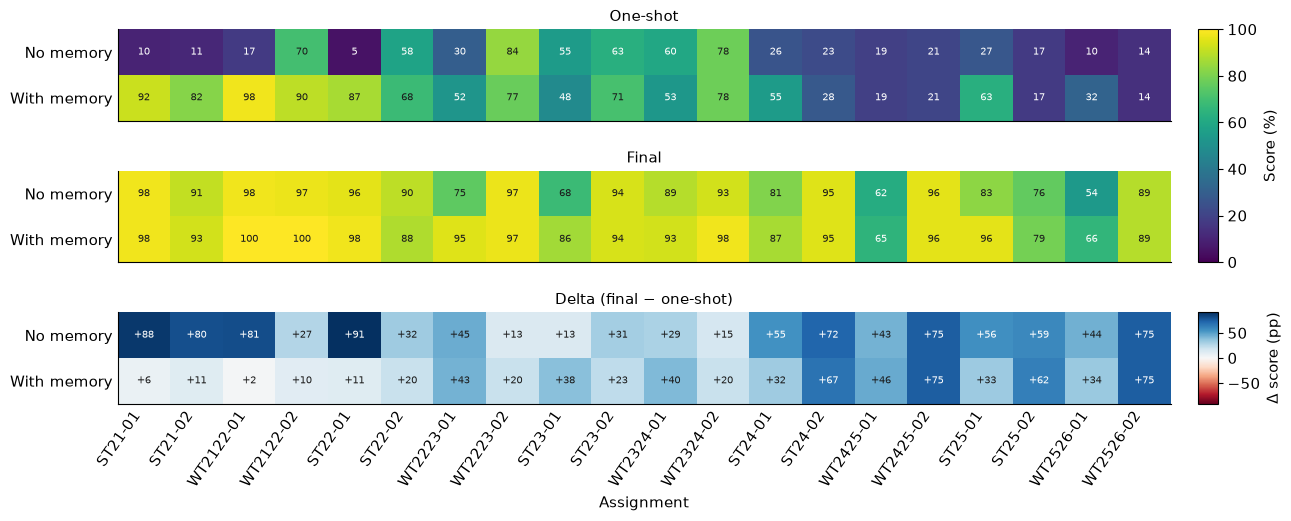

In [3]:
def _text_color_for_cell(value, cmap, norm):
    """Pick black/white label text from the cell's mapped luminance."""
    r, g, b, _ = cmap(norm(value))
    luma = 0.299 * r + 0.587 * g + 0.114 * b
    return "#1a1a1a" if luma > 0.55 else "white"


def _annotate_heatmap(ax, matrix, cmap, norm, fmt="{:.0f}"):
    """Write cell values on top of an imshow grid."""
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            ax.text(
                j, i, fmt.format(value),
                ha="center", va="center", fontsize=7,
                color=_text_color_for_cell(value, cmap, norm),
            )


def plot_score_heatmaps(one_shot_df, final_df, delta_df):
    """Horizontal heatmaps: assignments on x, conditions on y; panels stacked.

    Returns (fig, panel_specs) where panel_specs feed save_heatmap_tikz.
    """
    assignment_labels = list(one_shot_df.index.astype(str))
    condition_labels = [CONDITION_LABELS[c] for c in CONDITION_ORDER]
    condition_labels_tikz = [CONDITION_LABELS_SHORT[c] for c in CONDITION_ORDER]

    delta_data = delta_df.to_numpy(dtype=float).T
    delta_vmax = max(abs(delta_data.min()), abs(delta_data.max()), 1)

    panel_specs = [
        {
            "data": one_shot_df.to_numpy(dtype=float).T,
            "title": "One-shot",
            "cmap": plt.get_cmap("viridis"),
            "norm": Normalize(0, 100),
            "fmt": "{:.0f}",
            # TikZ: horizontal bar between One-shot and Final (shared scale).
            "colorbar_label": "Score (%)",
        },
        {
            "data": final_df.to_numpy(dtype=float).T,
            "title": "Final",
            "cmap": plt.get_cmap("viridis"),
            "norm": Normalize(0, 100),
            "fmt": "{:.0f}",
            "colorbar_label": None,
        },
        {
            "data": delta_data,
            # Use ASCII "--" so TikZ/LaTeX needs no unicode minus.
            "title": "Delta (final -- one-shot)",
            "cmap": plt.get_cmap("RdBu"),
            "norm": Normalize(-delta_vmax, delta_vmax),
            "fmt": "{:+.0f}",
            "colorbar_label": r"$\Delta$ score (pp)",
        },
    ]

    fig, axes = plt.subplots(
        3, 1, figsize=(13.5, 5.2), sharex=True,
        gridspec_kw={"hspace": 0.55},
    )

    images = []
    for ax, panel in zip(axes, panel_specs):
        im = ax.imshow(panel["data"], cmap=panel["cmap"], norm=panel["norm"], aspect="auto")
        images.append(im)
        _annotate_heatmap(ax, panel["data"], panel["cmap"], panel["norm"], fmt=panel["fmt"])
        ax.set_title(panel["title"].replace("--", "−"), fontsize=11, pad=6)
        ax.set_yticks(range(len(condition_labels)))
        ax.set_yticklabels(condition_labels)
        ax.set_xticks(range(len(assignment_labels)))
        ax.tick_params(length=0)

    axes[-1].set_xticklabels(assignment_labels, rotation=55, ha="right")
    axes[-1].set_xlabel("Assignment")

    fig.subplots_adjust(left=0.10, right=0.88, top=0.94, bottom=0.22)
    pos0 = axes[0].get_position()
    pos1 = axes[1].get_position()
    pos2 = axes[2].get_position()
    cax_score = fig.add_axes([0.90, pos1.y0, 0.015, pos0.y1 - pos1.y0])
    cax_delta = fig.add_axes([0.90, pos2.y0, 0.015, pos2.height])
    cbar_score = fig.colorbar(images[0], cax=cax_score)
    cbar_score.set_label("Score (%)")
    cbar_delta = fig.colorbar(images[2], cax=cax_delta)
    cbar_delta.set_label("Δ score (pp)")
    return fig, panel_specs, assignment_labels, condition_labels_tikz


fig, panel_specs, assignment_labels, condition_labels = plot_score_heatmaps(
    one_shot, final, delta
)
pdf_path = FIGURES_DIR / "score_heatmaps.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
tex_path = save_heatmap_tikz(panel_specs, assignment_labels, condition_labels, "score_heatmaps")
print(f"Saved {pdf_path.relative_to(PROJECT_ROOT)} and {tex_path.relative_to(PROJECT_ROOT)}")


## 2. Loop counts — grouped bars

How many feedback loops each assignment needed under each condition. This is
a different claim from final-score improvement: memory may (or may not) reach
a similar final score in fewer correction cycles.

X-axis = 20 assignments; two bars per assignment (no memory / with memory).
Loop count = max iteration index (= number of correction steps after the
one-shot).

Saved output/figures/loop_counts.pdf and output/tikz/loop_counts.tex


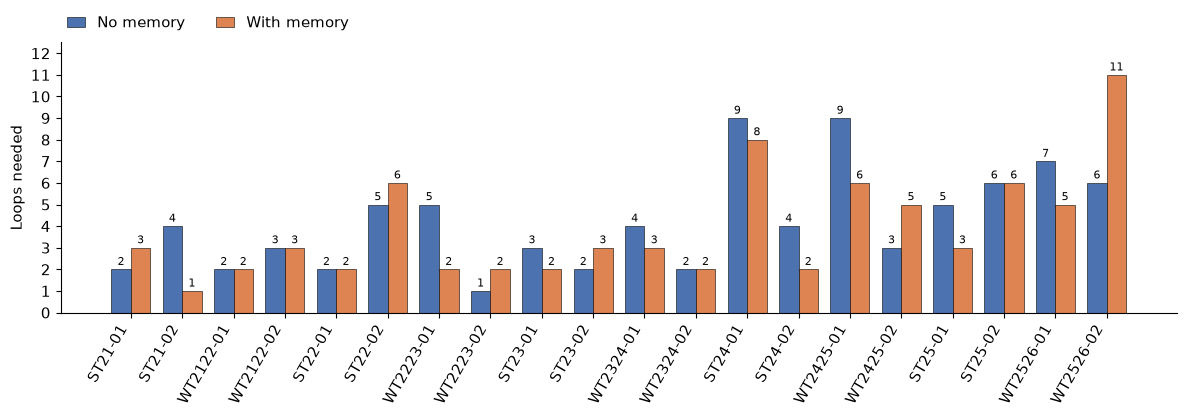

In [4]:
def plot_loop_counts(loops_df):
    x = np.arange(len(loops_df))
    width = 0.38
    # 12 × 4.5 → TikZ height=0.375\\linewidth at width=\\linewidth (thesis fit).
    fig, ax = plt.subplots(figsize=(12, 4.5))

    bars_nm = ax.bar(
        x - width / 2, loops_df["no_memory"], width,
        label=CONDITION_LABELS["no_memory"], color=NO_MEMORY_COLOR,
        edgecolor="black", linewidth=0.4,
    )
    bars_m = ax.bar(
        x + width / 2, loops_df["memory"], width,
        label=CONDITION_LABELS["memory"], color=MEMORY_COLOR,
        edgecolor="black", linewidth=0.4,
    )

    ax.set_ylabel("Loops needed")
    ax.set_xticks(x)
    ax.set_xticklabels(list(loops_df.index.astype(str)), rotation=60, ha="right")
    ymax = int(loops_df.to_numpy().max())
    ax.set_ylim(0, ymax + 1.5)
    ax.set_yticks(range(0, ymax + 2))
    # Park the legend above the plotting area so tall bars cannot cover it.
    ax.legend(
        frameon=False, loc="lower left", bbox_to_anchor=(0, 1.02),
        ncol=2, borderaxespad=0, handlelength=1.2,
    )

    for bars in (bars_nm, bars_m):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.08, f"{int(h)}",
                    ha="center", va="bottom", fontsize=8)

    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig


fig = plot_loop_counts(loops)
save_figure(fig, "loop_counts", axis_options=OPEN_FRAME_AXIS, strip_xlabel=True)


## 3. Per-assignment trajectories — small multiples

Score at each iteration for both conditions, one panel per assignment. Shows
*how* the feedback loop climbed (steep early gains vs. long plateaus), which
the heatmaps and loop-count bars cannot show.

All 20 assignments are drawn on a shared 0–100 y-scale; panels where memory
finishes earlier simply stop their orange line sooner.

Saved output/figures/score_trajectories.pdf and output/tikz/score_trajectories.tex


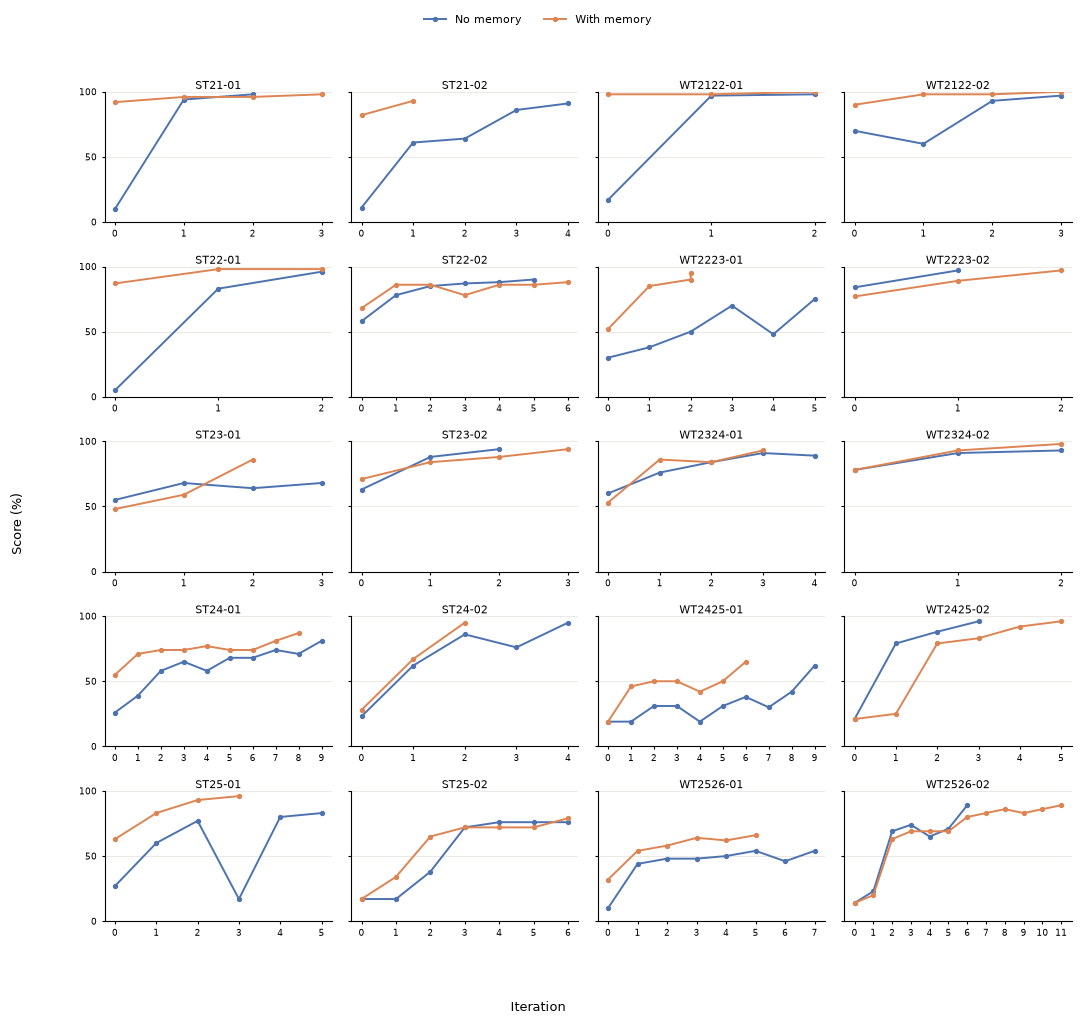

In [5]:
def plot_trajectories(raw_df, assignments, ncols=4):
    """Matplotlib small-multiples preview (PDF). TikZ uses save_trajectories_tikz."""
    n = len(assignments)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(11, 2.0 * nrows),
        sharex=False, sharey=True,
    )
    axes = np.atleast_2d(axes)

    for idx, assignment in enumerate(assignments):
        ax = axes[idx // ncols, idx % ncols]
        subset = raw_df[raw_df["assignment"] == assignment]
        for condition, color in (("no_memory", NO_MEMORY_COLOR), ("memory", MEMORY_COLOR)):
            traj = subset[subset["condition"] == condition].sort_values("iteration")
            ax.plot(
                traj["iteration"], traj["score"],
                color=color, marker="o", markersize=2.8, linewidth=1.4,
                label=CONDITION_LABELS[condition],
            )
        ax.set_title(str(assignment), fontsize=8, pad=2)
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 50, 100])
        ax.set_xticks(range(0, int(subset["iteration"].max()) + 1))
        ax.grid(axis="y", color="#e1e0d9", linewidth=0.5)
        ax.tick_params(labelsize=6.5, length=2)

    for idx in range(n, nrows * ncols):
        axes[idx // ncols, idx % ncols].axis("off")

    fig.supylabel("Score (%)", fontsize=9)
    fig.supxlabel("Iteration", fontsize=9)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=2, frameon=False,
        bbox_to_anchor=(0.5, 1.02), fontsize=8,
    )
    fig.tight_layout(rect=(0.04, 0.04, 1, 0.96))
    return fig, ncols


fig, traj_ncols = plot_trajectories(raw, ASSIGNMENTS)
pdf_path = FIGURES_DIR / "score_trajectories.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
tex_path = save_trajectories_tikz(raw, ASSIGNMENTS, "score_trajectories", ncols=traj_ncols)
print(f"Saved {pdf_path.relative_to(PROJECT_ROOT)} and {tex_path.relative_to(PROJECT_ROOT)}")
